In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d uciml/human-activity-recognition-with-smartphones

Dataset URL: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones
License(s): CC0-1.0
100% 24.5M/24.5M [00:00<00:00, 124MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('human-activity-recognition-with-smartphones.zip', 'r') as zip_ref:
    zip_ref.extractall('HAR_dataset')

In [ ]:
import pandas as pd

train = pd.read_csv('HAR_dataset/train.csv')
test = pd.read_csv('HAR_dataset/test.csv')

X_train = train.drop('Activity', axis=1)
y_train = train['Activity']

X_test = test.drop('Activity', axis=1)
y_test = test['Activity']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9300984051577876
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.91       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.90      0.97      0.94       496
WALKING_DOWNSTAIRS       0.97      0.85      0.90       420
  WALKING_UPSTAIRS       0.89      0.92      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [ ]:
import numpy as np

probs = model.predict_proba(X_test)
confidence = np.max(probs, axis=1)

threshold = 0.85

incorrect_flag = confidence < 0.85

In [ ]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred,
    'Confidence': confidence,
    'Incorrect_Movement': incorrect_flag
})

# Step 1: Severity Score
results['Severity_Score'] = (1 - results['Confidence']) * 100

# Step 2: Severity Level
def severity_label(score):
    if score < 10:
        return "Good"
    elif score < 20:
        return "Moderate"
    else:
        return "Needs Improvement"

results['Severity_Level'] = results['Severity_Score'].apply(severity_label)

results.head()

,Actual,Predicted,Confidence,Incorrect_Movement,Severity_Score,Severity_Level
0,STANDING,STANDING,0.886667,False,11.333333,Moderate
1,STANDING,STANDING,0.860000,False,14.000000,Moderate
2,STANDING,STANDING,0.853333,False,14.666667,Moderate
3,STANDING,STANDING,0.866667,False,13.333333,Moderate
4,STANDING,STANDING,0.960000,False,4.000000,Good


In [ ]:
def recommend_exercise(activity):
    if activity == 'SITTING':
        return 'Stretching / Light Yoga'
    elif activity == 'STANDING':
        return 'Posture Correction Exercises'
    elif activity == 'WALKING':
        return 'Cardio Training'
    elif activity == 'LAYING':
        return 'Physiotherapy Relaxation'
    else:
        return 'General Fitness Exercise'

In [ ]:
results['Recommendation'] = results['Predicted'].apply(recommend_exercise)

results.head(10)

,Actual,Predicted,Confidence,Incorrect_Movement,Severity_Score,Severity_Level,Recommendation
0,STANDING,STANDING,0.886667,False,11.333333,Moderate,Posture Correction Exercises
1,STANDING,STANDING,0.860000,False,14.000000,Moderate,Posture Correction Exercises
2,STANDING,STANDING,0.853333,False,14.666667,Moderate,Posture Correction Exercises
3,STANDING,STANDING,0.866667,False,13.333333,Moderate,Posture Correction Exercises
4,STANDING,STANDING,0.960000,False,4.000000,Good,Posture Correction Exercises
5,STANDING,STANDING,0.933333,False,6.666667,Good,Posture Correction Exercises
6,STANDING,STANDING,0.920000,False,8.000000,Good,Posture Correction Exercises
7,STANDING,STANDING,0.920000,False,8.000000,Good,Posture Correction Exercises
8,STANDING,STANDING,0.733333,True,26.666667,Needs Improvement,Posture Correction Exercises
9,STANDING,STANDING,0.760000,True,24.000000,Needs Improvement,Posture Correction Exercises


In [ ]:
def severity_label(score):
    if score < 10:
        return "Good"
    elif score < 20:
        return "Moderate"
    else:
        return "Needs Improvement"

results['Severity_Level'] = results['Severity_Score'].apply(severity_label)

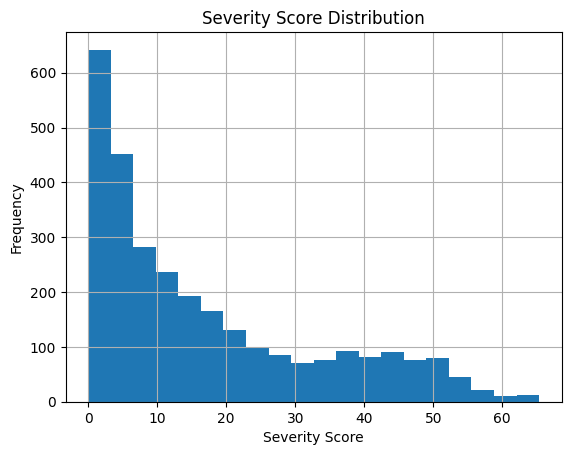

In [ ]:
import matplotlib.pyplot as plt

results['Severity_Score'].hist(bins=20)
plt.title("Severity Score Distribution")
plt.xlabel("Severity Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=150)
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name}: {acc}")

Decision Tree: 0.8574821852731591
SVM: 0.9307770614183916
Random Forest: 0.9253478113335596


In [ ]:
thresholds = [0.6, 0.7, 0.8, 0.85, 0.9]
results_list = []

for t in thresholds:
    incorrect = (confidence < t).sum()
    results_list.append((t, incorrect))

print(results_list)

[(0.6, np.int64(385)), (0.7, np.int64(633)), (0.8, np.int64(948)), (0.85, np.int64(1211)), (0.9, np.int64(1523))]


<Axes: >

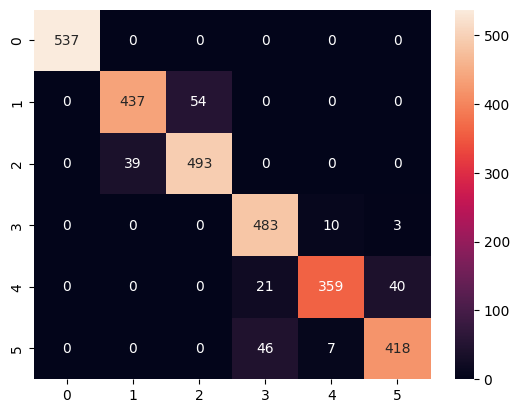

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')

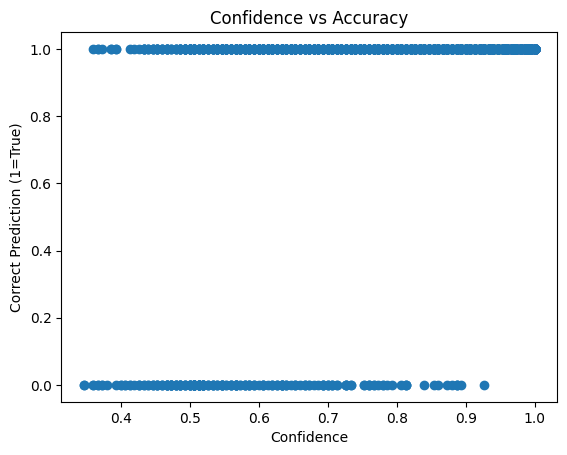

In [ ]:
correct = (pred == y_test)

import matplotlib.pyplot as plt

plt.scatter(confidence, correct)
plt.xlabel("Confidence")
plt.ylabel("Correct Prediction (1=True)")
plt.title("Confidence vs Accuracy")
plt.show()

In [ ]:
import time

start = time.time()
model.predict(X_test)
end = time.time()

print("Inference Time:", end - start)

Inference Time: 0.20487570762634277


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes = sorted(y_test.unique())

y_test_bin = label_binarize(y_test, classes=classes)
probs = model.predict_proba(X_test)

# Compute overall AUC
auc_score = roc_auc_score(y_test_bin, probs, multi_class='ovr')

print("AUC:", auc_score)

AUC: 0.9952019948253618


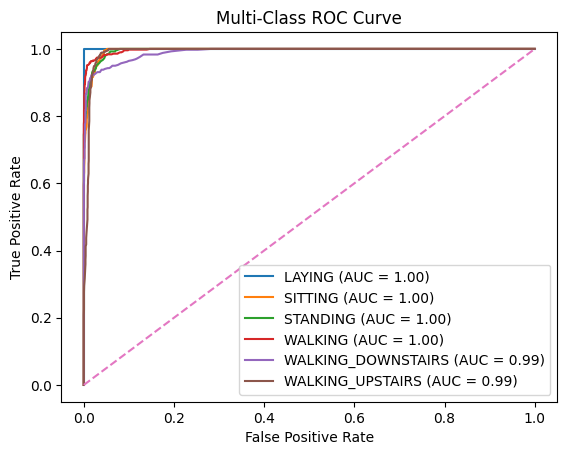

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Prepare data
classes = sorted(y_test.unique())
y_test_bin = label_binarize(y_test, classes=classes)
probs = model.predict_proba(X_test)

# Plot ROC for each class
plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

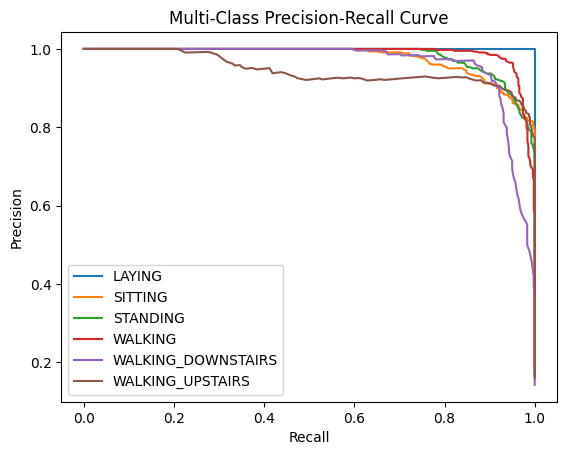

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
    plt.plot(recall, precision, label=f"{classes[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multi-Class Precision-Recall Curve")
plt.legend()
plt.show()

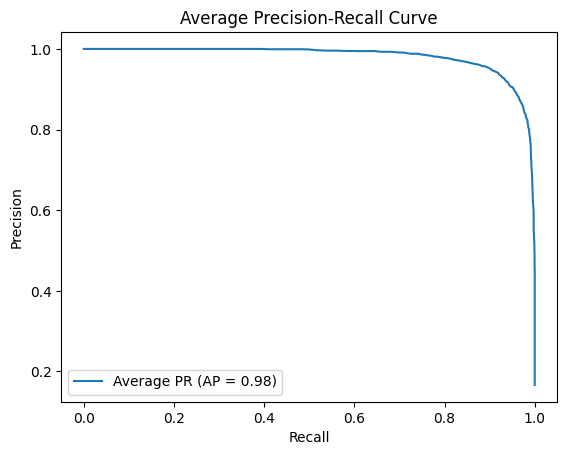

In [ ]:
from sklearn.metrics import average_precision_score

avg_precision = average_precision_score(y_test_bin, probs, average='macro')

precision, recall, _ = precision_recall_curve(
    y_test_bin.ravel(), probs.ravel()
)

plt.plot(recall, precision, label=f"Average PR (AP = {avg_precision:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Average Precision-Recall Curve")
plt.legend()
plt.show()

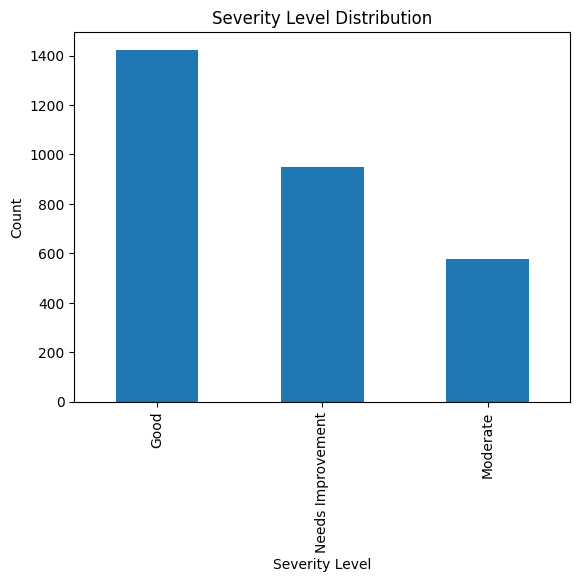

In [ ]:
results['Severity_Level'].value_counts().plot(kind='bar')
plt.title("Severity Level Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()

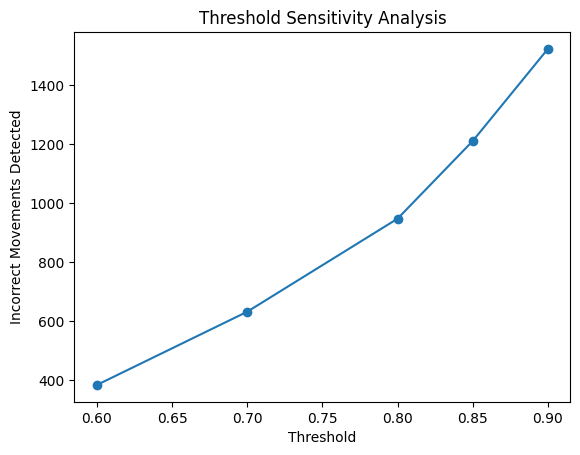

In [ ]:
thresholds = [0.6, 0.7, 0.8, 0.85, 0.9]
counts = [385, 633, 948, 1211, 1523]

plt.plot(thresholds, counts, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Incorrect Movements Detected")
plt.title("Threshold Sensitivity Analysis")
plt.show()

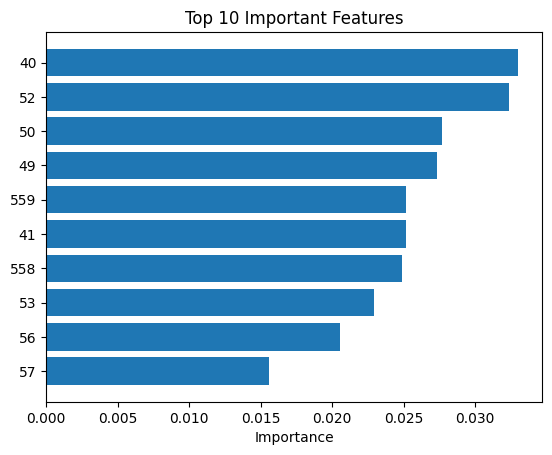

In [ ]:
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]  # top 10 features

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

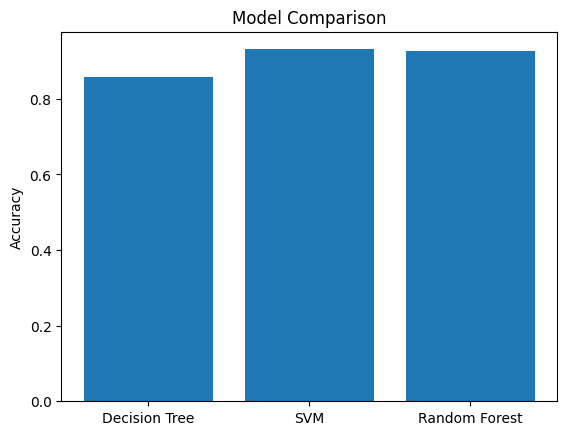

In [ ]:
models = ['Decision Tree', 'SVM', 'Random Forest']
accuracies = [0.857, 0.9307, 0.9253]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()